In [1]:
# Importing Libs
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import time

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings



sns.set_theme(style="darkgrid", rc={'figure.figsize':(10,6)})

In [2]:
FRAUD_PATH = "datasets/AIML Dataset.csv"

df = pd.read_csv(FRAUD_PATH)

categorical_features = ['type', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
numerical_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df['balanceOrigDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']

features_model = numerical_features + ['balanceOrigDiff', 'balanceDestDiff', 'isFraud']
df_model = df[features_model]

df_model.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceOrigDiff,balanceDestDiff,isFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,-9839.64,0.0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,-1864.28,0.0,0
2,1,181.00,181.0,0.00,0.0,0.0,-181.00,0.0,1
3,1,181.00,181.0,0.00,21182.0,0.0,-181.00,-21182.0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,-11668.14,0.0,0


In [3]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42)

In [5]:
scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Random Forest Classifier

In [8]:
models = {
    'Dummy Classifier': DummyClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier(),
    'LGBM': LGBMClassifier()
}

MODEL_EVALUATION_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "average_precision",
    "neg_brier_score",
    "f1_weighted",
]

In [9]:
# Redundante. Remover depois

def train_model(TRAIN_X: pd.DataFrame, TRAIN_Y, MODEL, CV, SCORING):

    results = {}

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")

        for model_name, classifier in MODEL.items():
            results[model_name] = cross_validate(estimator = classifier, 
                                                 X = TRAIN_X, 
                                                 y = TRAIN_Y, 
                                                 cv = CV,
                                                 scoring = SCORING)

    return results

In [10]:
# results = train_model(MODEL = models, TRAIN_X = X_train, TRAIN_Y = y_train, CV = stratified_kfold, SCORING = MODEL_EVALUATION_METRICS)

[LightGBM] [Info] Number of positive: 4599, number of negative: 3558468
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 3563067, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Info] Number of positive: 4599, number of negative: 3558468
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 3563067, number of used features: 8
[LightGBM] [In

In [ ]:
# results

In [20]:
def results_to_df(model_results, sum_time):
    df = pd.DataFrame(model_results)
    df = df.T

    # list of columns
    col_list = df.columns.tolist()

    df = df.explode(col_list)

    df = df.reset_index()

    df[col_list] = df[col_list].astype(float)
    
    df.rename(columns={'index': 'models'}, inplace=True)

    if sum_time:
        df['total_time'] = df['fit_time'] + df['score_time']
        df = df.drop(columns=['fit_time', 'score_time'])

        
    return(df)

In [22]:
# df_results = results_to_df(results, sum_time = True)
# df_results

,models,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,test_neg_brier_score,test_f1_weighted,total_time
0,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.003167
1,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.014988
2,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.044028
3,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.014383
4,Dummy Classifier,0.998710,0.500000,0.000000,0.000000,0.000000,0.500000,0.001290,-0.001288,0.998066,0.998774
5,Logistic Regression,0.999248,0.739525,0.621896,0.885852,0.479130,0.962167,0.609952,-0.000694,0.999136,3.816759
6,Logistic Regression,0.999233,0.734307,0.612152,0.882160,0.468696,0.958897,0.612170,-0.000695,0.999116,4.006289
7,Logistic Regression,0.999273,0.746919,0.636771,0.895899,0.493913,0.954672,0.619977,-0.000670,0.999167,3.576479
8,Logistic Regression,0.999255,0.738660,0.623156,0.897059,0.477391,0.955283,0.616341,-0.000681,0.999141,3.899590
9,Logistic Regression,0.999223,0.737113,0.611672,0.860979,0.474326,0.959104,0.604394,-0.000710,0.999111,3.689301


In [24]:
# df_results.groupby("models").mean().sort_values("test_average_precision")

,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,test_neg_brier_score,test_f1_weighted,total_time
models,,,,,,,,,,
Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.015068
Naive Bayes,0.990131,0.737086,0.113866,0.064692,0.483387,0.908744,0.080000,-0.009109,0.993900,2.089577
LGBM,0.998702,0.808350,0.563186,0.524741,0.617506,0.840920,0.398930,-0.001291,0.998787,8.839791
Logistic Regression,0.999246,0.739305,0.621129,0.884390,0.478691,0.958025,0.612567,-0.000690,0.999134,3.797684
KNN,0.999411,0.810178,0.730990,0.889611,0.620455,0.876654,0.672981,-0.000550,0.999358,197.882854
Decision Tree,0.999577,0.912581,0.834364,0.843655,0.825360,0.912581,0.696581,-0.000423,0.999575,72.085618
XGB,0.999675,0.898818,0.863685,0.941667,0.797700,0.999120,0.932269,-0.000258,0.999662,10.384924


In [26]:
def box_pair(df, x_val, y_val, titles, y_ax_label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # CASH_OUT piechart
    ax1 = sns.boxplot(data = df, x = x_val, y = y_val[0], color = 'skyblue', showfliers=True, ax=axes[0])
    
    ax1.set_title(label = titles[0], fontsize="medium", loc="center")
    ax1.set_ylabel(ylabel = y_ax_label[0])
    ax1.tick_params(axis="x", rotation=45, labelsize="x-small")
    ax1.tick_params(axis="y", labelsize="x-small")
    
    
    
    # TRANSFER piechart
    ax2 = sns.boxplot(data = df, x = x_val, y = y_val[1], color = 'skyblue', showfliers=False, ax=axes[1])
    
    ax2.set_title(label = titles[1], fontsize="medium", loc="center")
    ax2.set_ylabel(ylabel = y_ax_label[1])
    ax2.tick_params(axis="x", rotation=45, labelsize="x-small")
    ax2.tick_params(axis="y", labelsize="x-small")
    
    plt.show()
    return(None)
    
        

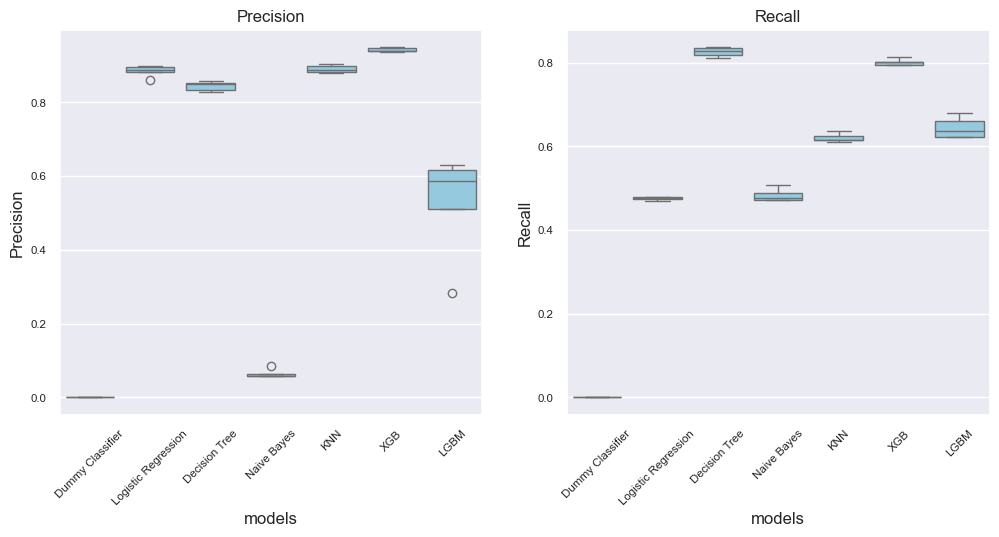

In [28]:
box_pair(df = df_results, x_val = "models", y_val = ["test_precision", "test_recall"],
        titles = ["Precision", "Recall"], y_ax_label = ["Precision", "Recall"])

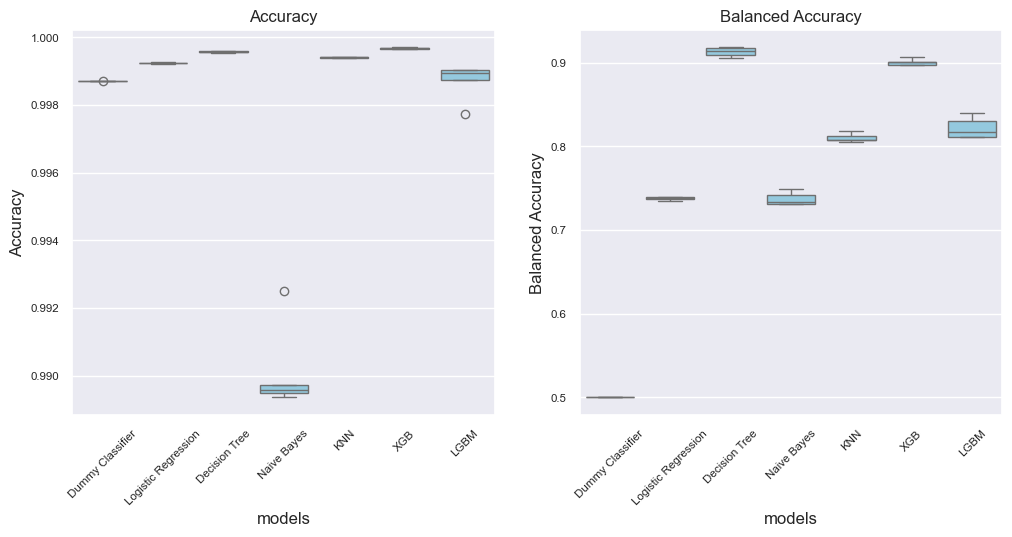

In [29]:
box_pair(df = df_results, x_val = "models", y_val = ["test_accuracy", "test_balanced_accuracy"],
        titles = ["Accuracy", "Balanced Accuracy"], y_ax_label = ["Accuracy", "Balanced Accuracy"])

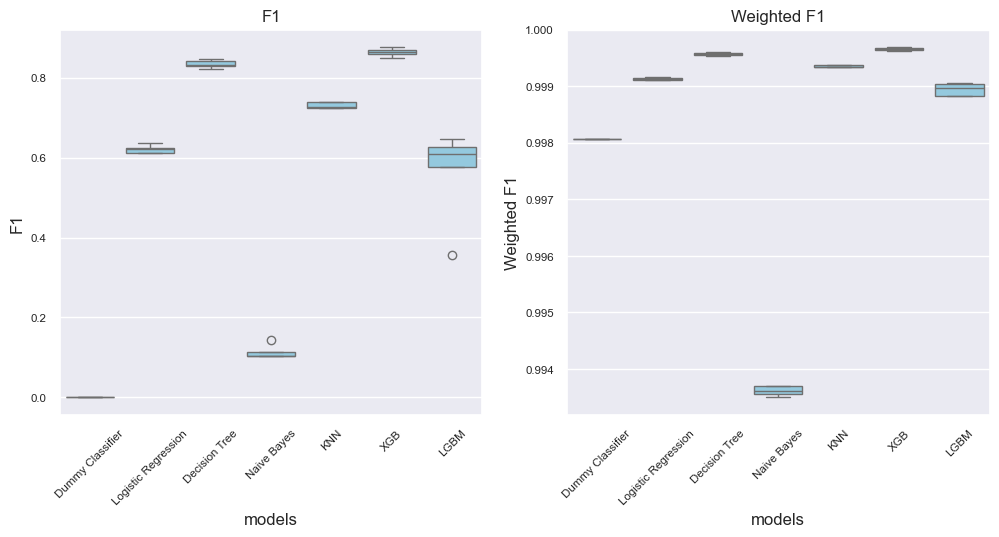

In [30]:
box_pair(df = df_results, x_val = "models", y_val = ["test_f1", "test_f1_weighted"],
        titles = ["F1", "Weighted F1"], y_ax_label = ["F1", "Weighted F1"])

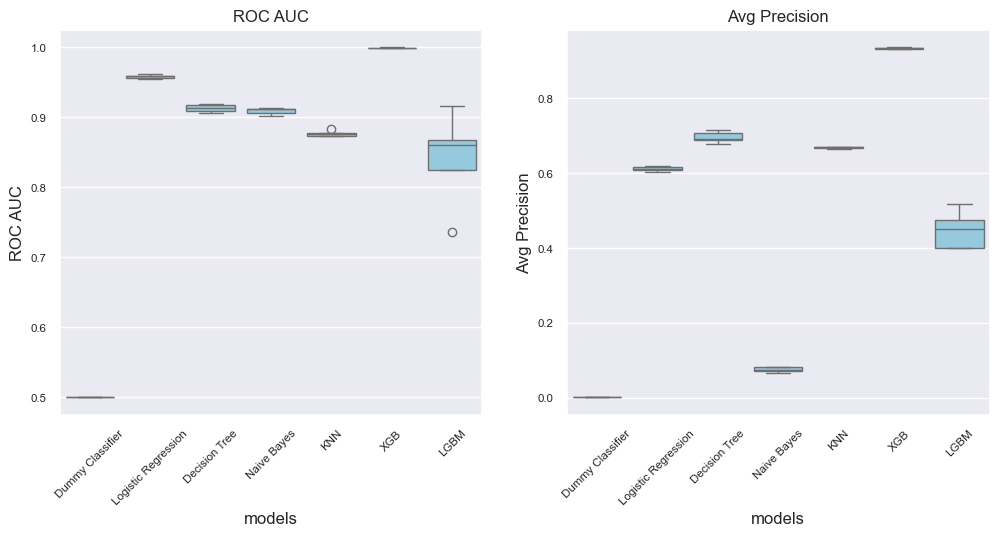

In [32]:
box_pair(df = df_results, x_val = "models", y_val = ["test_roc_auc", "test_average_precision"],
        titles = ["ROC AUC", "Avg Precision"], y_ax_label = ["ROC AUC", "Avg Precision"])

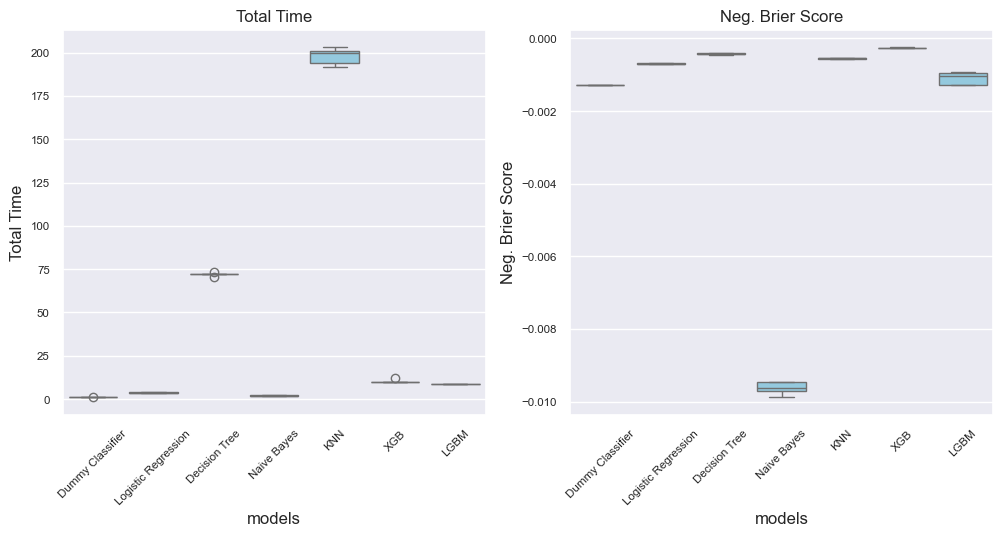

In [33]:
box_pair(df = df_results, x_val = "models", y_val = ["total_time", "test_neg_brier_score"],
        titles = ["Total Time", "Neg. Brier Score"], y_ax_label = ["Total Time", "Neg. Brier Score"])

In [13]:
# Instância do modelo
xgb = XGBClassifier(use_label_encoder=False, 
                    eval_metric='logloss', 
                    random_state=42)

# Dicionário de hiperparâmetros a serem testados
param_grid = {
    'n_estimators': [100, 300, 350],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.8, 1, 1.2]
}

In [15]:
# Estratégia de validação cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
# Instância do GridSearch
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',  # você pode trocar por 'roc_auc', 'f1', etc.
    cv=cv_strategy,
    n_jobs=1,
    verbose=2
)

In [19]:
# Ajustando o modelo com os dados de treino
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    
    grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=  10.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   9.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   9.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=  14.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=  11.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  10.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  11.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  10.7s
[CV] END 

In [21]:
# Resultados
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor recall:", grid_search.best_score_)

Melhores parâmetros: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 350, 'subsample': 0.8}
Melhor recall: 0.8110942596586824


In [23]:
import joblib
filename = 'best_grid_model_beta2.joblib'

joblib.dump(grid_search.best_estimator_, filename)

['best_grid_model_beta2.joblib']

In [87]:
# Resultados
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor recall:", grid_search.best_score_)

Melhores parâmetros: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Melhor recall: 0.7891804420688932


In [70]:
# Resultados # Tentativa com 2 CV
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor recall:", grid_search.best_score_)

Melhores parâmetros: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Melhor recall: 0.7797882666182567
